## imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
import multiprocess
from ult import *

# use new data

In [3]:
modelname = 'varyrewardperoid2'
# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0
no_episodes = 6666
epochtouse = 8

attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
seed = 0
np.random.seed(seed)

vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
env_param = [0, None, attcost, .25, facost, 0, 0]

thismodel = f'seed_{seed}_{modelname}_{modeli}'

task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2
model = PPO.load(f'ycstore/{thismodel}_epoch_{epochtouse}')
print(f'ycstore/{thismodel}_epoch_{epochtouse}')

episode = run_one_episode(task, taskbelief, model,
                          num_steps=1000, deterministic=False)


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ycstore/seed_0_varyrewardperoid2_0_epoch_8


# use saved data

In [4]:
# save
# save_pickle_file(f'single_trial_plot/data.pkl', episode)


# load
episode=open_pickle_file('single_trial_plot/data.pkl')

# plot

/Users/yc/repo/auditory-foraging-IRC/ult.py:565: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:264.)
  nolicknoatt = np.exp(pi.log_prob(torch.tensor(


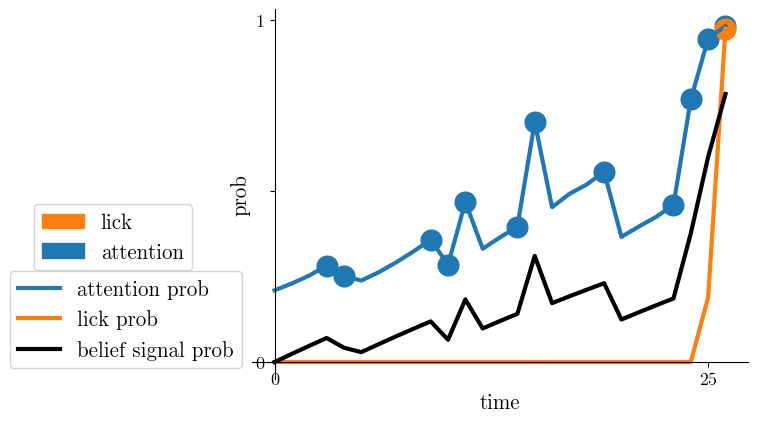

In [5]:
# curves
timeend=25
att_probs, lick_probs, noise_probs, time = get_att_lick_probs_new(
    episode, model)

att = np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[
    0]-1  # remove the start iti
lick = episode['actions'][-1][0] == 1


fig = plt.figure()
plt.plot(att_probs, label='attention prob', color=attn_color, linewidth=3)
plt.scatter(np.array(list(range(len(att_probs))))[att], np.array(
    att_probs)[att], color=attn_color, marker='o', s=222)

plt.plot(lick_probs, label='lick prob', color=lick_color, linewidth=3)
if lick:
    plt.scatter(len(lick_probs)-1,
                lick_probs[-1], color=lick_color, marker='o', s=222)

plt.plot([1-noise_prob for noise_prob in noise_probs],
         label='belief signal prob', color=sig_color, linewidth=3)

ax = plt.gca()
centerax(ax)
plt.yticks([0, .5, 1], ['0', '', '1'])
plt.xticks([0, timeend])
plt.xlabel('time')
plt.ylabel('prob')


# Create Patch objects for the custom legend
lickdot = Patch(color=lick_color, label='lick')
attdot = Patch(color=attn_color, label='attention')
extra_legend = plt.legend(
    handles=[lickdot, attdot], bbox_to_anchor=(-0.1, 0.5), frameon=True)

ax.add_artist(extra_legend)
quickleg(ax)

plt.show()

# quicksave('episode curve', modelname,fig=fig)

In [6]:
state=episode['states'][1:-1]!=0
state=state
obs = episode['observations'][1:-1]
att=[elt[1] for elt in episode['actions'][:-1]]
b=episode['beliefs'][1:-1, 1:26] # time, signal dim
att=np.array(att).reshape(-1,1)
# cmap
start_rgb = noise_color # noise
end_rgb = sig_color # signal
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])


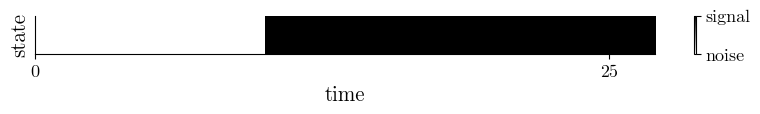

In [7]:

# state (noise signal peroid)
fig, ax=plt.subplots(1,1,figsize=(10,0.5))
c=plt.imshow(state.reshape(-1,1).T, aspect='auto', cmap=custom_cmap)
cbar=plt.colorbar(c, ticks=[0,1])
cbar.set_ticklabels(['noise', 'signal']) 
plt.xlabel('time')
plt.ylabel('state')
plt.yticks([])
plt.xticks([0-0.5,timeend-0.5], [0,timeend])
plt.show()



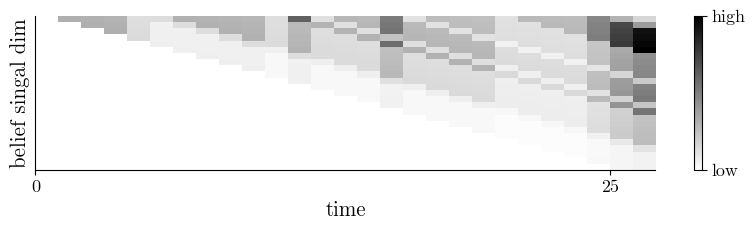

In [8]:

# belief
fig, ax=plt.subplots(1,1,figsize=(10,2))
c=plt.imshow(b.T, aspect='auto', cmap=custom_cmap)
cbar=plt.colorbar(c, ticks=[0,np.max(b)])
cbar.set_ticklabels(['low', 'high']) 
plt.xlabel('time')
plt.ylabel('belief singal dim')
plt.yticks([])
plt.xticks([0-0.5,timeend-0.5], [0,timeend])
plt.show()



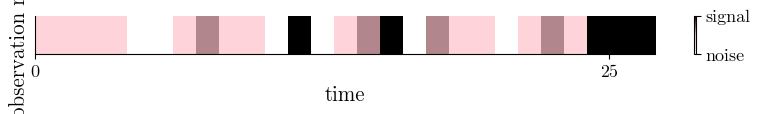

In [10]:
# obs result
res=[]
shading=0.3
for o,a in zip(obs, att):
    if a==1: 
        if o==0: res.append(-1)
        else: res.append(1)
    elif a==0:
        if o==0: res.append(-shading)
        else: res.append(shading)
res=np.array(res)

fig, ax=plt.subplots(1,1,figsize=(10,0.5))
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', [noise_color,'pink', sig_color])
plt.imshow(res.reshape(1,-1),  cmap=custom_cmap, vmin=-1, vmax=1)
c=plt.imshow(res.reshape(1,-1), aspect='auto', cmap=custom_cmap)
cbar=plt.colorbar(c, ticks=[-1,1])
cbar.set_ticklabels(['noise', 'signal']) 
plt.xlabel('time')
plt.ylabel('observation result')
plt.yticks([])
plt.xticks([0-0.5,timeend-0.5], [0,timeend])
plt.show()
